In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['OPENCV_LOG_LEVEL'] = 'SILENT'
import sys

import warnings
warnings.filterwarnings("ignore")

import cv2
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)
sys.stderr = open(os.devnull, 'w')

E0000 00:00:1775718222.283226      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775718222.406662      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775718223.427459      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775718223.427495      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775718223.427498      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775718223.427501      55 computation_placer.cc:177] computation placer already registered. Please check linka

In [6]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.applications import VGG16, VGG19, MobileNet, MobileNetV2

print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [7]:
DATA_PATH = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset"
ANNOT_PATH = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations"
SAVE_PATH = "/kaggle/working/"

In [8]:
from collections import defaultdict  
import random
all_folders = [f for f in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, f))]

grouped = defaultdict(list)

for folder in all_folders:
    key = folder[0].upper()
    grouped[key].append(folder)

selected_folders = []

for letter in sorted(grouped.keys()):
    folders = grouped[letter]
    random.shuffle(folders)
    pick = folders[:min(2, len(folders))]
    selected_folders.extend(pick)

selected_folders = selected_folders[:50]

print("Total Selected Folders:", len(selected_folders))

Total Selected Folders: 47


In [9]:
data = []

for embryo_folder in selected_folders:

    embryo_path = os.path.join(DATA_PATH, embryo_folder)

    csv_name = embryo_folder + "_phases.csv"
    csv_path = os.path.join(ANNOT_PATH, csv_name)

    if not os.path.exists(csv_path):
        continue

    df_csv = pd.read_csv(csv_path, header=None)
    df_csv.columns = ["phase", "start", "end"]

    df_csv["start"] = df_csv["start"].astype(int)
    df_csv["end"] = df_csv["end"].astype(int)

    for img_name in os.listdir(embryo_path):

        if not img_name.endswith(".jpeg"):
            continue

        try:
            frame = int(img_name.split("RUN")[-1].split(".")[0])
        except:
            continue

        for _, row in df_csv.iterrows():
            if row["start"] <= frame <= row["end"]:
                label = row["phase"]
                img_path = os.path.join(embryo_path, img_name)
                data.append((embryo_folder, img_path, label))
                break

df = pd.DataFrame(data, columns=["folder_name", "image_path", "class_name"])

label_map = {label: idx for idx, label in enumerate(df["class_name"].unique())}
df["label"] = df["class_name"].map(label_map)

csv_path = SAVE_PATH + "final_embryo_dataset.csv"
df.to_csv(csv_path, index=False)

print("Saved CSV:", csv_path)

Saved CSV: /kaggle/working/final_embryo_dataset.csv


In [10]:
strategy = tf.distribute.MirroredStrategy()
print("Number of devices:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


In [11]:
df = pd.read_csv("/kaggle/working/final_embryo_dataset.csv")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

IMG_SIZE = 128
NUM_CLASSES = df["label"].nunique()

In [12]:
def generator(dataframe, batch_size=32):
    while True:
        dataframe = dataframe.sample(frac=1)

        for i in range(0, len(dataframe), batch_size):
            batch = dataframe.iloc[i:i+batch_size]

            images, labels = [], []

            for _, row in batch.iterrows():
                try:
                    img = cv2.imread(row["image_path"])

                    if img is None or img.size == 0:
                        continue

                    if len(img.shape) != 3:
                        continue

                    img = cv2.resize(img, (128,128)) / 255.0

                    images.append(img)
                    labels.append(row["label"])

                except:
                    continue

            if len(images) < batch_size:
                continue

            yield np.array(images), tf.keras.utils.to_categorical(labels, NUM_CLASSES)

In [13]:
train_gen = generator(train_df)
test_gen = generator(test_df)

In [14]:
def directional_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

    indices = tf.cast(tf.range(tf.shape(y_pred)[1]), tf.float32)
    pred_index = tf.reduce_sum(y_pred * indices, axis=1)
    true_index = tf.cast(tf.argmax(y_true, axis=1), tf.float32)

    distance = tf.square(pred_index - true_index)
    backward = tf.nn.relu(true_index - pred_index)

    return ce + 0.3 * distance + 0.5 * backward

In [15]:
def build_vgg16():
    base = VGG16(weights="imagenet", include_top=False, input_shape=(128,128,3))
    for l in base.layers: l.trainable=False

    x = Flatten()(base.output)
    x = Dense(128, activation="relu")(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)

    return Model(base.input, out)

In [16]:
def build_vgg19():
    base = VGG19(weights="imagenet", include_top=False, input_shape=(128,128,3))
    for l in base.layers: l.trainable=False

    x = Flatten()(base.output)
    x = Dense(128, activation="relu")(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)

    return Model(base.input, out)

In [17]:
def build_mobilenetv1():
    base = MobileNet(weights="imagenet", include_top=False, input_shape=(128,128,3))
    for l in base.layers: l.trainable=False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation="relu")(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)

    return Model(base.input, out)

In [18]:
def build_mobilenetv2():
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(128,128,3))
    for l in base.layers: l.trainable=False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation="relu")(x)
    out = Dense(NUM_CLASSES, activation="softmax")(x)

    return Model(base.input, out)

In [19]:
def inception_module(x, f1, f3r, f3, f5r, f5, f_pool):
    conv1 = Conv2D(f1,(1,1),activation='relu',padding='same')(x)

    conv3 = Conv2D(f3r,(1,1),activation='relu',padding='same')(x)
    conv3 = Conv2D(f3,(3,3),activation='relu',padding='same')(conv3)

    conv5 = Conv2D(f5r,(1,1),activation='relu',padding='same')(x)
    conv5 = Conv2D(f5,(5,5),activation='relu',padding='same')(conv5)

    pool = MaxPooling2D((3,3),strides=1,padding='same')(x)
    pool = Conv2D(f_pool,(1,1),activation='relu')(pool)

    return Concatenate()([conv1,conv3,conv5,pool])

def build_inception_v1():
    inputs = Input((128,128,3))

    x = Conv2D(64,(7,7),strides=2,padding='same',activation='relu')(inputs)
    x = MaxPooling2D((3,3),strides=2,padding='same')(x)

    x = Conv2D(64,(1,1),activation='relu')(x)
    x = Conv2D(192,(3,3),padding='same',activation='relu')(x)
    x = MaxPooling2D((3,3),strides=2,padding='same')(x)

    x = inception_module(x,64,96,128,16,32,32)
    x = inception_module(x,128,128,192,32,96,64)

    x = MaxPooling2D((3,3),strides=2,padding='same')(x)

    x = inception_module(x,192,96,208,16,48,64)
    x = inception_module(x,160,112,224,24,64,64)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='relu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(NUM_CLASSES,activation='softmax')(x)

    return Model(inputs,outputs)

In [20]:
from PIL import Image

bad_images = []

for path in df["image_path"]:
    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_images.append(path)

print("Bad images:", len(bad_images))

Bad images: 0


In [21]:
df = df[~df["image_path"].isin(bad_images)]

In [22]:

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_gen = generator(train_df)
test_gen = generator(test_df)

In [23]:
print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

Train samples: 15401
Test samples: 3851


In [24]:
from tensorflow.keras.models import load_model
import pandas as pd

def train_model(name, build_fn, loss_fn):

    print(f"\n Starting: {name}")

    best_path = f"/kaggle/working/{name}_best.keras"
    backup_path = f"/kaggle/working/{name}_backup.keras"
    log_path = f"/kaggle/working/{name}_log.csv"

    
    if os.path.exists(backup_path):
        print(" Resuming from backup...")

        model = load_model(
            backup_path,
            custom_objects={"directional_loss": directional_loss}
        )

        if os.path.exists(log_path):
            log = pd.read_csv(log_path)
            initial_epoch = len(log)
        else:
            initial_epoch = 0

        print("Resuming from epoch:", initial_epoch)

    else:
        print("Starting fresh model...")   

        with strategy.scope():
            model = build_fn()
            model.compile(
                optimizer="adam",
                loss=loss_fn,
                metrics=["accuracy"]
            )

        model.summary()
        initial_epoch = 0

   
    best_ckpt = ModelCheckpoint(
        best_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )

    backup_ckpt = ModelCheckpoint(backup_path)

    logger = CSVLogger(log_path, append=True)


    history = model.fit(
        train_gen,
        steps_per_epoch=len(train_df)//64,
        validation_data=test_gen,
        validation_steps=len(test_df)//64,
        epochs=10,
        initial_epoch=initial_epoch,
        callbacks=[best_ckpt, backup_ckpt, logger]
    )

   
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(name)
    plt.legend()
    plt.grid()
    plt.show()

    
    loss, acc = model.evaluate(test_gen, steps=20)

    print(f"{name} Final Test Accuracy:", acc)
    print(f"{name} Final Test Loss:", loss)

    
    y_true, y_pred = [], []

    for _ in range(20):
        X, y = next(test_gen)
        preds = model.predict(X)

        y_true.extend(np.argmax(y, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, cmap="Blues", annot=True, fmt="d")
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model


 Starting: VGG16- categorical loss
Starting fresh model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,765,327 (60.14 MB)

 Trainable params: 1,050,639 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

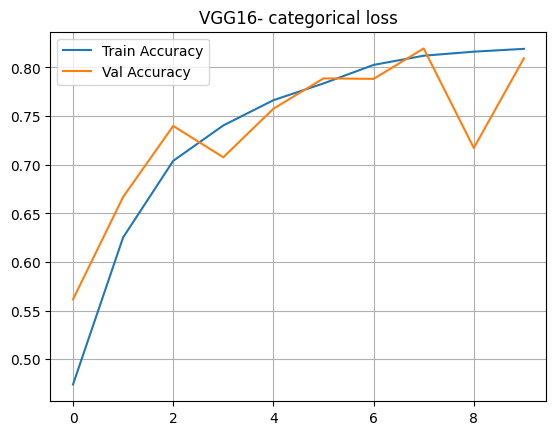

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8430 - loss: 0.4861
VGG16- categorical loss Final Test Accuracy: 0.824999988079071
VGG16- categorical loss Final Test Loss: 0.5044417381286621
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


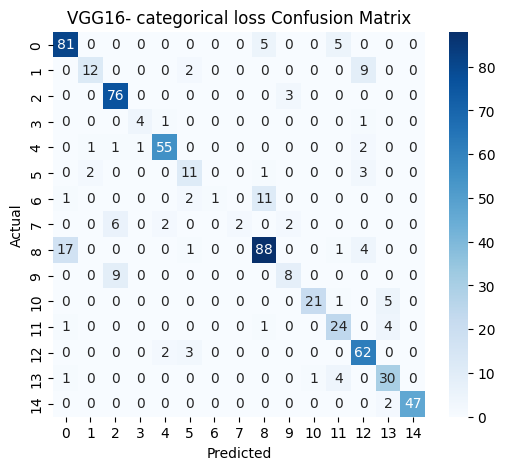


 Starting: VGG16- with custom loss + categorical loss
Starting fresh model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,765,327 (60.14 MB)

 Trainable params: 1,050,639 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
248/248 ━━━━━━━━━━━━━━━━━━━━ 30s 115ms/step - accuracy: 0.2728 - loss: 8.9452 - val_accuracy: 0.4466 - val_loss: 6.3627
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.4720 - loss: 5.9363 - val_accuracy: 0.5086 - val_loss: 5.6495
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.5266 - loss: 5.5844 - val_accuracy: 0.5696 - val_loss: 4.6225
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.5917 - loss: 4.6344 - val_accuracy: 0.6366 - val_loss: 4.4350
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 106ms/step - accuracy: 0.6418 - loss: 4.2082 - val_accuracy: 0.6522 - val_loss: 4.1972
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 106ms/step - accuracy: 0.6649 - loss: 4.0396 - val_accuracy: 0.6749 - val_loss: 3.5306
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step 

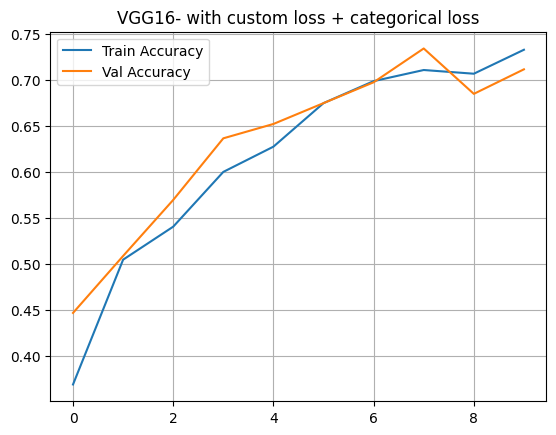

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.6689 - loss: 4.2339
VGG16- with custom loss + categorical loss Final Test Accuracy: 0.6859375238418579
VGG16- with custom loss + categorical loss Final Test Loss: 3.843649387359619
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

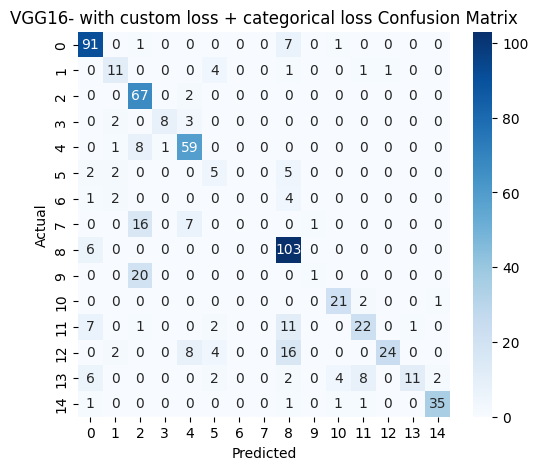


 Starting: VGG19- categorical loss
Starting fresh model...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         1,93

 Total params: 21,075,023 (80.39 MB)

 Trainable params: 1,050,639 (4.01 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
248/248 ━━━━━━━━━━━━━━━━━━━━ 29s 112ms/step - accuracy: 0.3425 - loss: 2.1473 - val_accuracy: 0.5418 - val_loss: 1.4094
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.5877 - loss: 1.2824 - val_accuracy: 0.6618 - val_loss: 1.0966
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.6490 - loss: 1.0522 - val_accuracy: 0.6376 - val_loss: 1.0337
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.5999 - loss: 4.2374 - val_accuracy: 0.6386 - val_loss: 4.0949
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.6347 - loss: 3.9535 - val_accuracy: 0.5741 - val_loss: 5.2808
Epoch 9/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.6601 - loss: 3.8784 - val_accuracy: 0.6310 - val_loss: 3.9992
Epoch 10/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - 

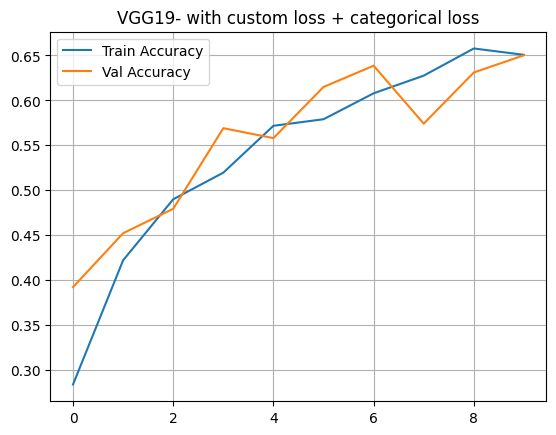

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.6547 - loss: 3.3647
VGG19- with custom loss + categorical loss Final Test Accuracy: 0.6656249761581421
VGG19- with custom loss + categorical loss Final Test Loss: 3.3239223957061768
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━

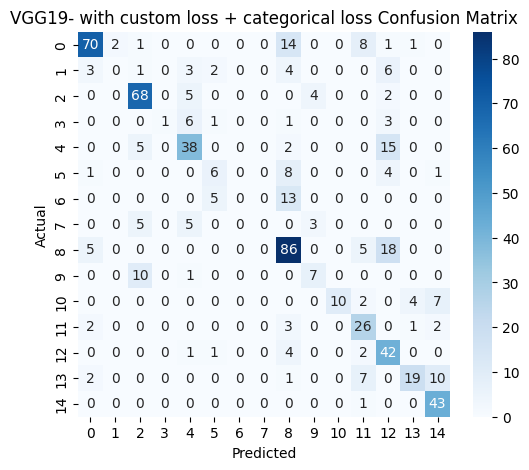


 Starting: MobileNetV1- categorical loss
Starting fresh model...
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 32, 32, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 32, 32, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 32, 32, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,361,999 (12.83 MB)

 Trainable params: 133,135 (520.06 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
248/248 ━━━━━━━━━━━━━━━━━━━━ 31s 113ms/step - accuracy: 0.4439 - loss: 1.7798 - val_accuracy: 0.6754 - val_loss: 0.9939
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.8271 - loss: 0.4973 - val_accuracy: 0.8342 - val_loss: 0.4683
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.8491 - loss: 0.4431 - val_accuracy: 0.8246 - val_loss: 0.5263
Epoch 9/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.8511 - loss: 0.4426 - val_accuracy: 0.8372 - val_loss: 0.4937
Epoch 10/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.8687 - loss: 0.3901 - val_accuracy: 0.8564 - val_loss: 0.4339


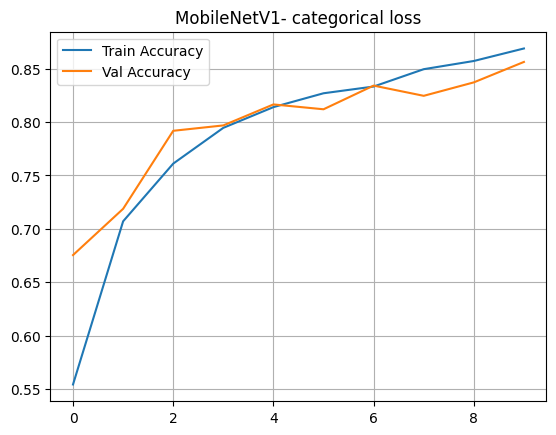

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8449 - loss: 0.4492
MobileNetV1- categorical loss Final Test Accuracy: 0.854687511920929
MobileNetV1- categorical loss Final Test Loss: 0.4345322549343109
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


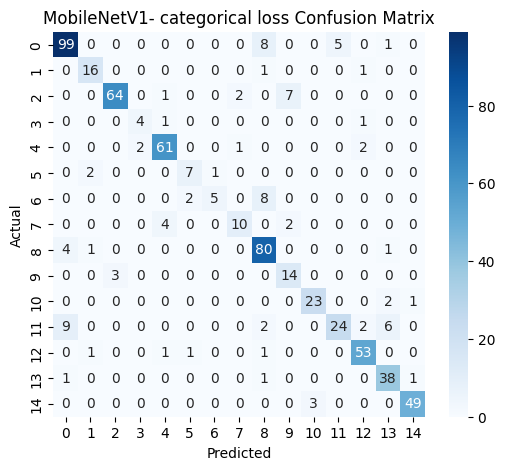


 Starting: MobileNetV1- with custom loss + categorical loss
Starting fresh model...


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 32, 32, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 32, 32, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 32, 32, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,361,999 (12.83 MB)

 Trainable params: 133,135 (520.06 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
248/248 ━━━━━━━━━━━━━━━━━━━━ 33s 121ms/step - accuracy: 0.3095 - loss: 8.2104 - val_accuracy: 0.4385 - val_loss: 6.4166
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 106ms/step - accuracy: 0.5365 - loss: 5.5330 - val_accuracy: 0.5922 - val_loss: 4.4835
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 106ms/step - accuracy: 0.6050 - loss: 4.4721 - val_accuracy: 0.6285 - val_loss: 4.4115
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - accuracy: 0.6775 - loss: 3.8385 - val_accuracy: 0.6830 - val_loss: 3.9591
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.7132 - loss: 3.5002 - val_accuracy: 0.6618 - val_loss: 4.2457
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - accuracy: 0.7402 - loss: 3.0962 - val_accuracy: 0.7576 - val_loss: 3.0158
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step -

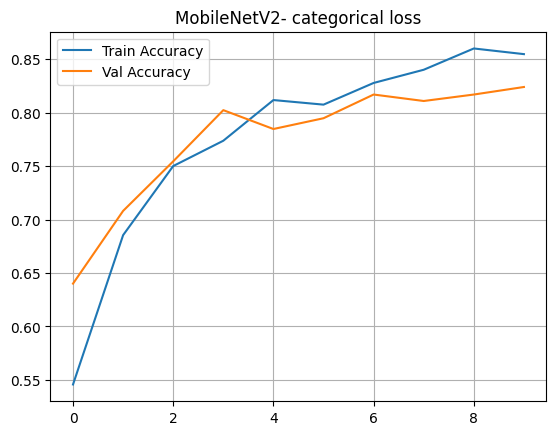

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8169 - loss: 0.5037
MobileNetV2- categorical loss Final Test Accuracy: 0.8218749761581421
MobileNetV2- categorical loss Final Test Loss: 0.5202858448028564
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


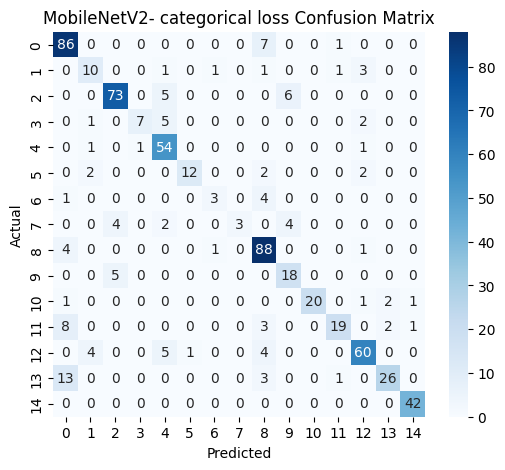


 Starting: MobileNetV2- with custom loss + categorical loss
Starting fresh model...


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
248/248 ━━━━━━━━━━━━━━━━━━━━ 36s 126ms/step - accuracy: 0.3297 - loss: 8.0868 - val_accuracy: 0.4914 - val_loss: 5.7572
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - accuracy: 0.5428 - loss: 5.3955 - val_accuracy: 0.5731 - val_loss: 4.7416
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 111ms/step - accuracy: 0.6219 - loss: 4.5649 - val_accuracy: 0.6593 - val_loss: 3.8828
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.6667 - loss: 3.7911 - val_accuracy: 0.6860 - val_loss: 3.6816
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - accuracy: 0.7114 - loss: 3.4451 - val_accuracy: 0.7112 - val_loss: 3.6750
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.7149 - loss: 3.4223 - val_accuracy: 0.7152 - val_loss: 3.6553
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step 

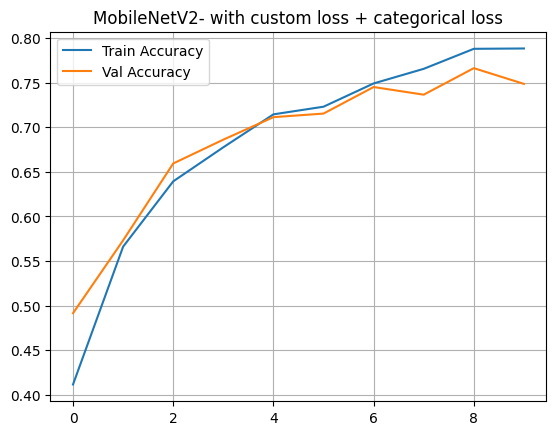

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.7387 - loss: 3.1785
MobileNetV2- with custom loss + categorical loss Final Test Accuracy: 0.75
MobileNetV2- with custom loss + categorical loss Final Test Loss: 3.2112534046173096
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

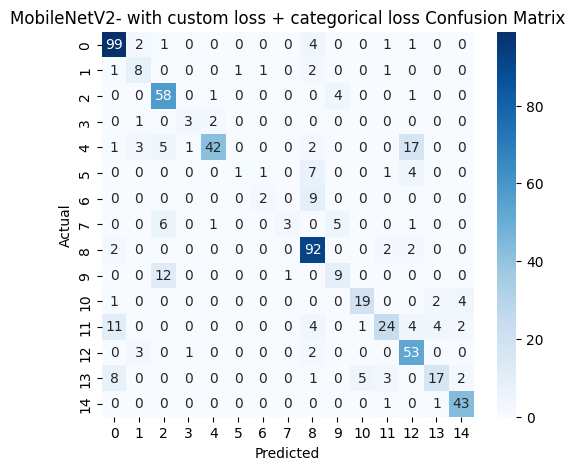


 Starting: InceptionV1- categorical loss
Starting fresh model...


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      9,472 │ input_layer_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    110,784 │ conv2d_1[0][0]    │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     18,528 │ max_pooling2d_1[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │      3,088 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ max_pooling2d_1[… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     12,352 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    110,720 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     12,832 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │      6,176 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │      8,224 │ concatenate[0][0] │
│                     │ 32)               │            │                 

 Total params: 1,637,367 (6.25 MB)

 Trainable params: 1,637,367 (6.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 58 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
248/248 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.1513 - loss: 2.5258 - val_accuracy: 0.1462 - val_loss: 2.4888
Epoch 2/10
 54/248 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.1506 - loss: 2.4994

In [ ]:
models = {
    "VGG16": build_vgg16,
    "VGG19": build_vgg19,
    "MobileNetV1": build_mobilenetv1,
    "MobileNetV2": build_mobilenetv2,
    "InceptionV1": build_inception_v1
}

for name, fn in models.items():

    train_model(name + "- categorical loss", fn, "categorical_crossentropy")

    train_model(name + "- with custom loss + categorical loss", fn, directional_loss)


 Starting: MobileNetV2- categorical loss
Starting fresh model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

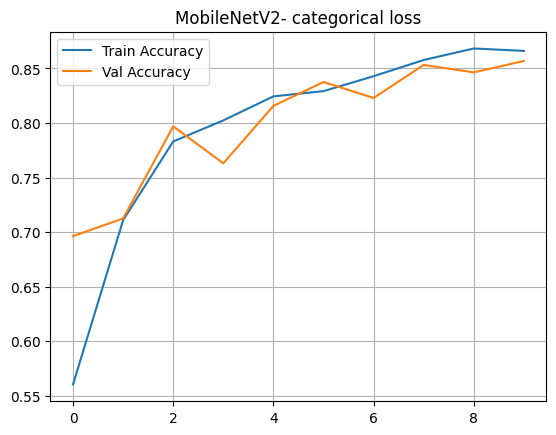

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.8369 - loss: 0.4998
MobileNetV2- categorical loss Final Test Accuracy: 0.8609374761581421
MobileNetV2- categorical loss Final Test Loss: 0.4356728196144104
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step


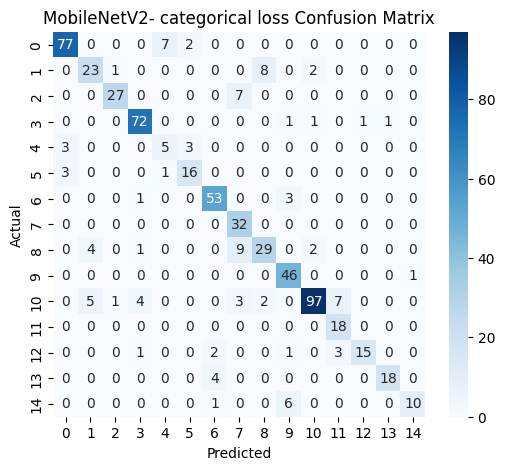


 Starting: MobileNetV2- with custom loss + categorical loss
Starting fresh model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
240/240 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.3574 - loss: 6.3423 - val_accuracy: 0.5750 - val_loss: 4.0069
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 34s 141ms/step - accuracy: 0.6084 - loss: 3.9674 - val_accuracy: 0.6422 - val_loss: 3.3024
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - accuracy: 0.6540 - loss: 3.4331 - val_accuracy: 0.6911 - val_loss: 3.3639
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 32s 134ms/step - accuracy: 0.7029 - loss: 2.8924 - val_accuracy: 0.7172 - val_loss: 2.6254
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 48s 203ms/step - accuracy: 0.7427 - loss: 2.6052 - val_accuracy: 0.7583 - val_loss: 2.4609
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 35s 146ms/step - accuracy: 0.7518 - loss: 2.4677 - val_accuracy: 0.7630 - val_loss: 2.3924
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 27s 111ms/step

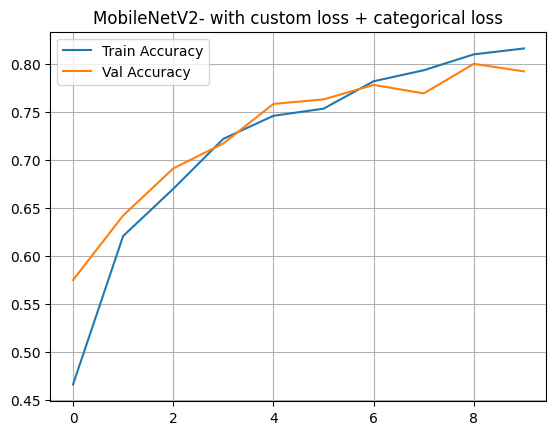

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.8153 - loss: 2.4049
MobileNetV2- with custom loss + categorical loss Final Test Accuracy: 0.8031250238418579
MobileNetV2- with custom loss + categorical loss Final Test Loss: 2.490875720977783
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━

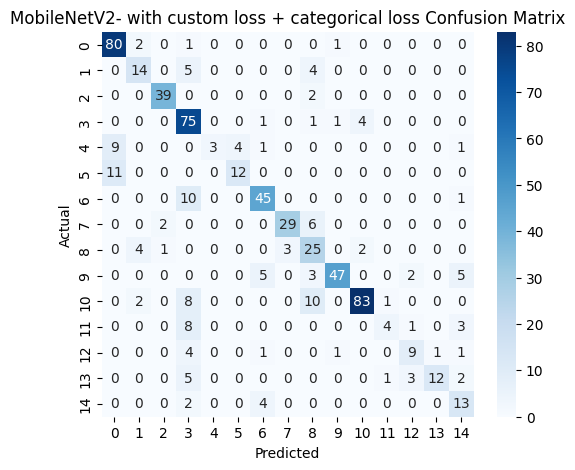


 Starting: InceptionV1- categorical loss
Starting fresh model...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      9,472 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    110,784 │ conv2d_1[0][0]    │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     18,528 │ max_pooling2d_1[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │      3,088 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ max_pooling2d_1[… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     12,352 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    110,720 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     12,832 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │      6,176 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │      8,224 │ concatenate[0][0] │
│                     │ 32)               │            │                 

 Total params: 1,637,367 (6.25 MB)

 Trainable params: 1,637,367 (6.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 58 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
240/240 ━━━━━━━━━━━━━━━━━━━━ 26s 108ms/step - accuracy: 0.1918 - loss: 2.4861 - val_accuracy: 0.2099 - val_loss: 2.4108
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.2157 - loss: 2.4077 - val_accuracy: 0.3141 - val_loss: 2.0787
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 26s 108ms/step - accuracy: 0.3356 - loss: 2.0369 - val_accuracy: 0.4187 - val_loss: 1.6409
Epoch 9/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.4220 - loss: 1.6905 - val_accuracy: 0.5089 - val_loss: 1.3811
Epoch 10/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 40s 139ms/step - accuracy: 0.1663 - loss: 8.7426 - val_accuracy: 0.1677 - val_loss: 8.5474
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 31s 131ms/step - accuracy: 0.1853 - loss: 8.6083 - val_accuracy: 0.1677 - val_loss: 8.6178
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 32s 134ms/st

In [ ]:
models = {
    "MobileNetV2": build_mobilenetv2,
    "InceptionV1": build_inception_v1
}

for name, fn in models.items():

  
    train_model(name + "- categorical loss", fn, "categorical_crossentropy")

    train_model(name + "- with custom loss + categorical loss", fn, directional_loss)

In [ ]:
from tensorflow.keras.models import load_model
import pandas as pd

def train_model(name, build_fn, loss_fn):

    print(f"\n Starting: {name}")

    best_path = f"/kaggle/working/{name}_best.keras"
    backup_path = f"/kaggle/working/{name}_backup.keras"
    log_path = f"/kaggle/working/{name}_log.csv"

    
    if os.path.exists(backup_path):
        print(" Resuming from backup...")

        model = load_model(
            backup_path,
            custom_objects={"directional_loss": directional_loss}
        )

        if os.path.exists(log_path):
            log = pd.read_csv(log_path)
            initial_epoch = len(log)
        else:
            initial_epoch = 0

        print("Resuming from epoch:", initial_epoch)

    else:
        print("Starting fresh model...")   

        with strategy.scope():
            model = build_fn()
            model.compile(
                optimizer="adam",
                loss=loss_fn,
                metrics=["accuracy"]
            )

        model.summary()
        initial_epoch = 0

   
    best_ckpt = ModelCheckpoint(
        best_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )

    backup_ckpt = ModelCheckpoint(backup_path)

    logger = CSVLogger(log_path, append=True)


    history = model.fit(
        train_gen,
        steps_per_epoch=len(train_df)//64,
        validation_data=test_gen,
        validation_steps=len(test_df)//64,
        epochs=50,
        initial_epoch=initial_epoch,
        callbacks=[best_ckpt, backup_ckpt, logger]
    )

   
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(name)
    plt.legend()
    plt.grid()
    plt.show()

    
    loss, acc = model.evaluate(test_gen, steps=20)

    print(f"{name} Final Test Accuracy:", acc)
    print(f"{name} Final Test Loss:", loss)

    
    y_true, y_pred = [], []

    for _ in range(20):
        X, y = next(test_gen)
        preds = model.predict(X)

        y_true.extend(np.argmax(y, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, cmap="Blues", annot=True, fmt="d")
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model

In [ ]:
models = {
    "InceptionV1": build_inception_v1
}

for name, fn in models.items():  

    train_model(name + "- categorical loss", fn, "categorical_crossentropy")

    train_model(name + "- with custom loss + categorical loss", fn, directional_loss)